Machine Learning models evaluation

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import LabelEncoder
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import tensorflow as tf

# Load data
features_df = pd.read_csv('../data/features/birdcall_features_TOP50.csv')

# Load top 18 features
top_features = [
    'lowlevel.spectral_energyband_middle_low.stdev',
    'lowlevel.hfc.stdev',
    'lowlevel.pitch_salience.stdev',
    'lowlevel.spectral_centroid.mean',
    'lowlevel.spectral_energyband_high.stdev',
    'lowlevel.spectral_complexity.mean',
    'lowlevel.spectral_decrease.stdev',
    'lowlevel.spectral_strongpeak.stdev',
    'lowlevel.spectral_complexity.stdev',
    'lowlevel.spectral_energyband_middle_low.mean',
    'lowlevel.spectral_strongpeak.mean',
    'lowlevel.loudness_ebu128.integrated',
    'lowlevel.erbbands_skewness.mean',
    'lowlevel.pitch.mean',
    'lowlevel.spectral_flux.stdev',
    'lowlevel.spectral_rolloff.mean',
    'lowlevel.spectral_energyband_middle_high.mean',
    'lowlevel.pitch_salience.mean'
]

X = features_df[top_features]
y = features_df['species']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# function to evaluate a model --> F1-Score, Confusion Matrix, Model training execution time and Inference execution time
def evaluate_model(model, X_test, y_test, label_encoder, model_name="Model"):
    # Timing inference
    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start

    # If model outputs probabilities, take argmax
    if y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)

    print(f"{model_name} Inference execution time: {inference_time:.2f} seconds")
    print(f"{model_name} Classification report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    print(f"{model_name} F1-Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

    # Confusion Matrix
    plt.figure(figsize=(12, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

KNN evaluation

In [ ]:
# start = time.time()
# knn_model = KNeighborsClassifier(...).fit(X_train, y_train)
# training_time = time.time() - start
# print(f"KNN Model training execution time: {training_time:.2f} seconds")
# evaluate_model(knn_model, X_test, y_test, label_encoder, model_name="KNN")

SVM evaluation

SVM Model training execution time: 1.39 seconds
SVM Inference execution time: 0.17 seconds
SVM Classification report:
                            precision    recall  f1-score   support

               Andean Guan       0.60      0.75      0.67        20
          Band-tailed Guan       0.59      0.65      0.62        20
            Barred Tinamou       0.91      1.00      0.95        20
        Bartlett's Tinamou       0.83      0.75      0.79        20
                Baudo Guan       1.00      1.00      1.00        20
              Bearded Guan       0.72      0.65      0.68        20
       Berlepsch's Tinamou       0.87      1.00      0.93        20
            Biak Scrubfowl       0.87      1.00      0.93        20
      Black-capped Tinamou       0.94      0.80      0.86        20
 Black-fronted Piping Guan       0.95      1.00      0.98        20
             Brown Tinamou       1.00      0.95      0.97        20
                Cauca Guan       0.94      0.80      0.86        

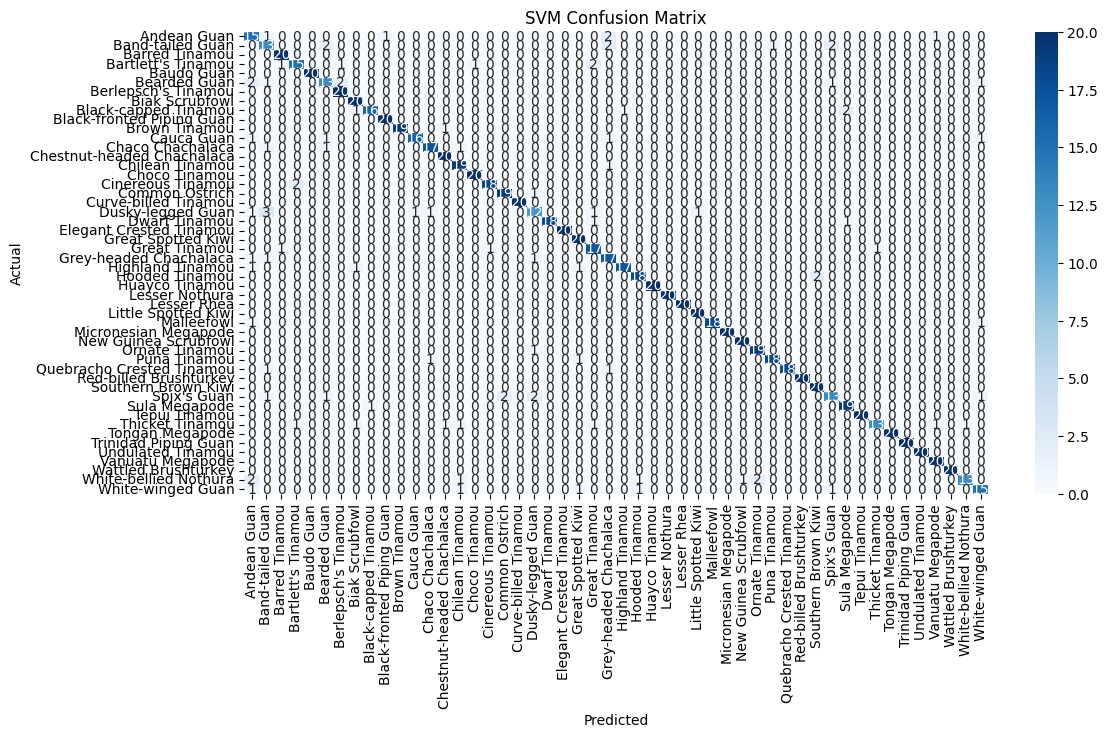

In [6]:
start = time.time()
svm_model = SVC(kernel='linear', probability=True, random_state=42).fit(X_train, y_train)
training_time = time.time() - start
print(f"SVM Model training execution time: {training_time:.2f} seconds")
evaluate_model(svm_model, X_test, y_test, label_encoder, model_name="SVM")

CNN evaluation

In [ ]:
# cnn_model = tf.keras.models.load_model('path_to_cnn_model.h5')
# start = time.time()
# cnn_model.fit(...)
# training_time = time.time() - start
# print(f"CNN Model training execution time: {training_time:.2f} seconds")
# evaluate_model(cnn_model, X_test, y_test, label_encoder, model_name="CNN")

CNN + LSTM evaluation

In [ ]:
# cnn_lstm_model = tf.keras.models.load_model('path_to_cnn_lstm_model.h5')
# start = time.time()
# cnn_lstm_model.fit(...)
# training_time = time.time() - start
# print(f"CNN+LSTM Model training execution time: {training_time:.2f} seconds")
# evaluate_model(cnn_lstm_model, X_test, y_test, label_encoder, model_name="CNN+LSTM")